In [6]:
import numpy as np
import sys
import matplotlib.pyplot as plt

sys.path.append('../../datasets')
from load_data import get_datasets

In [3]:
params = {'input_shape': [6000, 1], 'classes_filter': [], 'num_classes': 12}
ds_train, ds_val, ds_test, class_weights = get_datasets("speech_commands", params)

2024-03-05 16:53:46.951538: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-03-05 16:53:46.971806: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-03-05 16:53:46.975144: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-03-05 16:53:46.978653: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA
To enable them in other operations, rebuild TensorFlow wit

In [4]:
def get_class_distribution(ds):
    labels = [np.argmax(label) for _, label in ds]
    return np.bincount(labels, minlength=12)

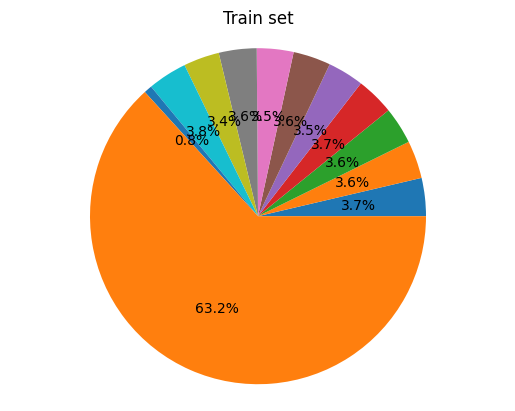

In [12]:
fig, ax = plt.subplots()
ax.pie(get_class_distribution(ds_train), autopct='%1.1f%%')
ax.axis('equal')
plt.title('Train set')
plt.show()

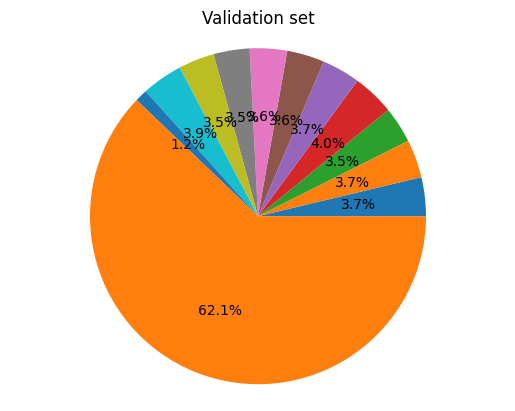

In [11]:
fig, ax = plt.subplots()
ax.pie(get_class_distribution(ds_val), autopct='%1.1f%%')
ax.axis('equal')
plt.title('Validation set')
plt.show()

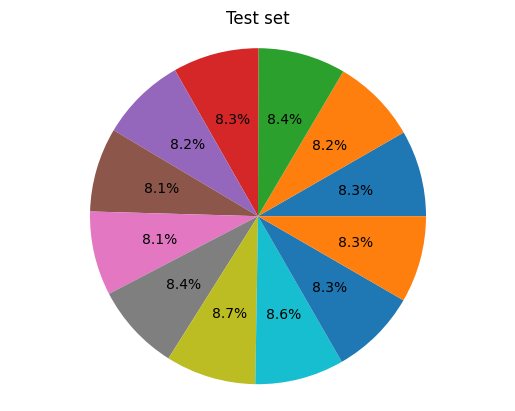

In [10]:
fig, ax = plt.subplots()
ax.pie(get_class_distribution(ds_test), autopct='%1.1f%%')
ax.axis('equal')
plt.title('Test set')
plt.show()

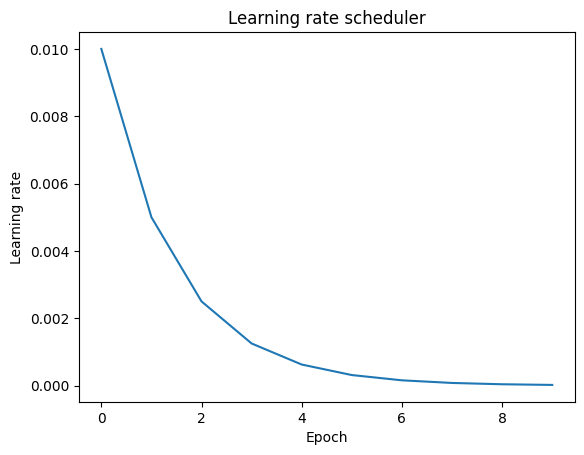

In [22]:
# visualize the following lr scheduler func: lambda epoch: 0.01 * 0.5 ** (epoch // 10)
epochs = range(10)
lrs = [0.01 * 0.5 ** epoch for epoch in epochs]
plt.plot(epochs, lrs)
plt.xlabel('Epoch')
plt.ylabel('Learning rate')
plt.title('Learning rate scheduler')
plt.show()
